In [88]:
import numpy as np
import matplotlib.pyplot as plt
import bacco

In [2]:
def read_cpu(filename=None, skiprows=[]):
    with open(filename) as f:
        lines = f.readlines()

    d = {}

    i=0
    for line in lines:
        line.strip()

        if i == 0:
            columns = [item.strip() for item in line.split(',')]
            for index, elem in enumerate(columns):
                d[columns[index]] = []
        elif i in skiprows:
            i = i + 1
            continue
        else:
            data = [item.strip() for item in line.split(',')]
            for index, elem in enumerate(columns):
                if index < 8:
                    d[columns[index]].append(float(data[index]))
                else:
                    d[columns[index]].append(float(data[index+1]))
        print(i)
        i = i + 1

    return d

In [3]:
# Read the file and extract the data for the given CPU name prefix and columns
def extract_data(filename):
    with open(filename, 'r') as file:
        reader = csv.reader(file, delimiter=',')
        header = next(reader)  # Skip the header row
        relevant_index = [i for i, col_name in enumerate(header)]
        data = {header[i]: [] for i, col_name in enumerate(header)}

        for row in reader:
            try:
                for i,col_name in enumerate(header):
                    data[col_name].append(float(row[i]))
            except:
                continue
    
    return data

In [5]:
def read_csv(filename):
    i=0
    with open(filename) as f:
        data = []
        lines = f.readlines()
        for line in lines:
            if i==51232 or i==137030:
                i+=1
                continue
            else:
                data.append(float(line.strip()))
                i+=1

    return np.array(data)

In [63]:
def load_scaling(base, ntasks, nhalos):
    data = {}

    data['expfactor'] = read_csv(base+'expfactor.csv')
    data['total_cpu'] = read_csv(base+'total_cpu.csv') / 3600 * ntasks / nhalos
    data['tree_cpu'] = read_csv(base+'tree_cpu.csv') / 3600 * ntasks / nhalos
    data['tree_walk_cpu'] = read_csv(base+'tree_walk_cpu.csv') / 3600 * ntasks / nhalos
    data['tree_bal_cpu'] = read_csv(base+'tree_bal_cpu.csv') / 3600 * ntasks / nhalos
    data['pm_cpu'] = read_csv(base+'pm_cpu.csv') / 3600 * ntasks / nhalos
    data['voronoi_cpu'] = read_csv(base+'voronoi_cpu.csv') / 3600 * ntasks / nhalos
    data['hydro_cpu'] = read_csv(base+'hydro_cpu.csv') / 3600 * ntasks / nhalos
    data['gfm_cpu'] = read_csv(base+'gfm_cpu.csv') / 3600 * ntasks / nhalos
    data['restart_cpu'] = read_csv(base+'restart_cpu.csv') / 3600 * ntasks / nhalos

    return data

In [64]:
base = "/cosmos_storage/data_sharing/MN5_resims/PM_512/halos_10/hydro_output/"
data_512 = load_scaling(base, 112, 10)

In [65]:
base = "/cosmos_storage/data_sharing/MN5_resims/PM_1024/halos_10/"
data_1024 = load_scaling(base, 112, 10)

In [106]:
base = "/cosmos_storage/data_sharing/MN5_resims/PM_1536/halos_10/"
data_1536 = load_scaling(base, 112, 10)

In [67]:
base = "/cosmos_storage/data_sharing/MN5_resims/PM_1792/halos_10/"
data_1792 = load_scaling(base, 112, 10)

In [68]:
base = "/cosmos_storage/data_sharing/MN5_resims/PM_512/halos_100/"
data_100_1536 = load_scaling(base, 112, 100)

In [70]:
def plot_cumulative(data, ax, len):
    keys = np.array(list(data.keys()))
    
    ax.grid()
    ax.fill_between(data['expfactor'][:len], np.zeros_like(data['total_cpu'][:len]), data['total_cpu'][:len], color=colors[6], label='Total')
    ax.fill_between(data['expfactor'][:len], np.zeros_like(data['total_cpu'][:len]), data['hydro_cpu'][:len], label='Hydro', color=colors[0])
    ax.fill_between(data['expfactor'][:len], data['hydro_cpu'][:len],\
                                             data['hydro_cpu'][:len] + data['voronoi_cpu'][:len], label='Voronoi', color=colors[1])
    ax.fill_between(data['expfactor'][:len], data['hydro_cpu'][:len] + data['voronoi_cpu'][:len],\
                                             data['hydro_cpu'][:len] + data['voronoi_cpu'][:len] + data['pm_cpu'][:len], label='PM', color=colors[2])
    ax.fill_between(data['expfactor'][:len], data['hydro_cpu'][:len] + data['voronoi_cpu'][:len] + data['pm_cpu'][:len],
                                             data['hydro_cpu'][:len] + data['voronoi_cpu'][:len] + data['pm_cpu'][:len] + data['tree_cpu'][:len], label='Tree-Grav', color=colors[3])
    ax.fill_between(data['expfactor'][:len], data['hydro_cpu'][:len] + data['voronoi_cpu'][:len] + data['pm_cpu'][:len] + data['tree_cpu'][:len], \
                                             data['hydro_cpu'][:len] + data['voronoi_cpu'][:len] + data['pm_cpu'][:len] + data['tree_cpu'][:len] + data['gfm_cpu'][:len], label='GFM', color=colors[4])
    ax.fill_between(data['expfactor'][:len], data['hydro_cpu'][:len] + data['voronoi_cpu'][:len] + data['pm_cpu'][:len] + data['tree_cpu'][:len] + data['gfm_cpu'][:len], \
                                             data['hydro_cpu'][:len] + data['voronoi_cpu'][:len] + data['pm_cpu'][:len] + data['tree_cpu'][:len] + data['gfm_cpu'][:len] + data['restart_cpu'][:len], label='Restart', color=colors[5])


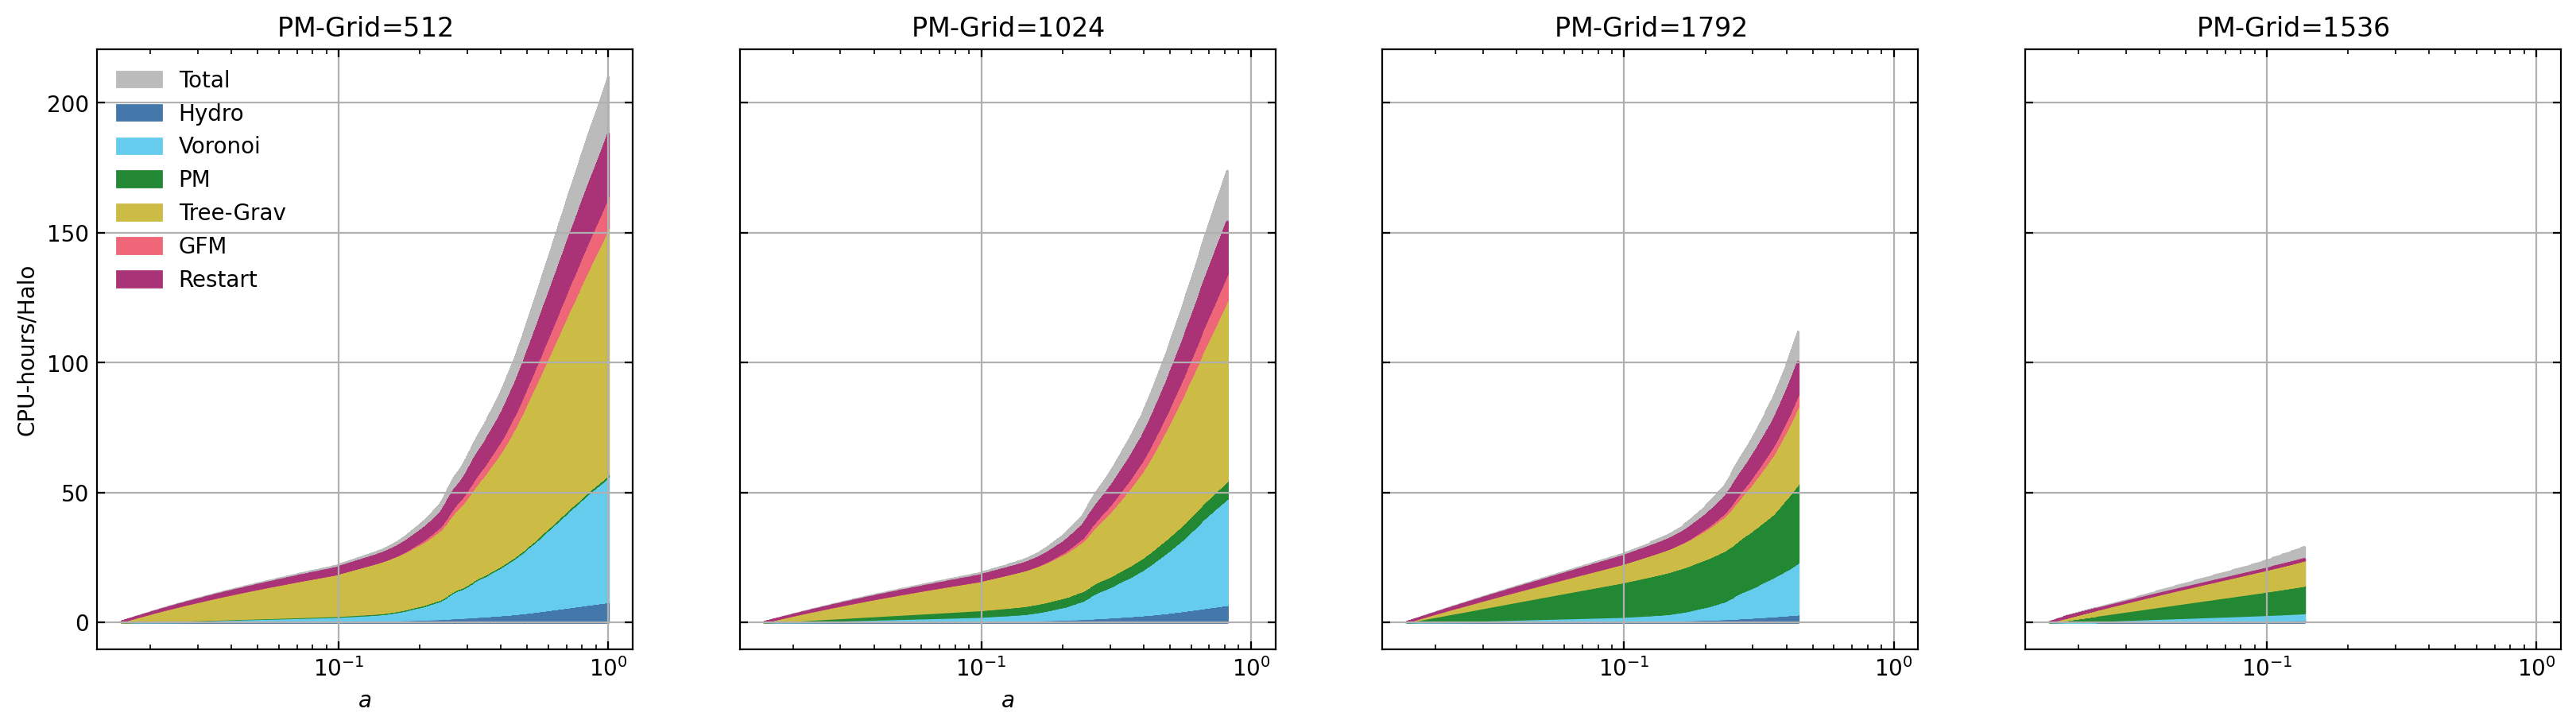

In [79]:
fig, ax = plt.subplots(1, 4, dpi=200, figsize=(20, 5), sharey=True, sharex=True)

ax[0].set_xscale('log')
ax[1].set_xscale('log')

#ax.set_yscale('log')

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

plot_cumulative(data_512, ax[0], 268528)

ax[0].set_title('PM-Grid=$512$')

plot_cumulative(data_1024, ax[1], 232186)

ax[1].set_title('PM-Grid=$1024$')

plot_cumulative(data_1792, ax[2], 116279)

ax[2].set_title('PM-Grid=$1792$')

plot_cumulative(data_1536, ax[3], 2416)

ax[3].set_title('PM-Grid=$1536$')

ax[0].set_xlabel('$a$')
ax[0].set_ylabel('CPU-hours/Halo')

ax[1].set_xlabel('$a$')

ax[0].legend(loc='upper left')

Text(0, 0.5, 'CPU-hours/Halo')

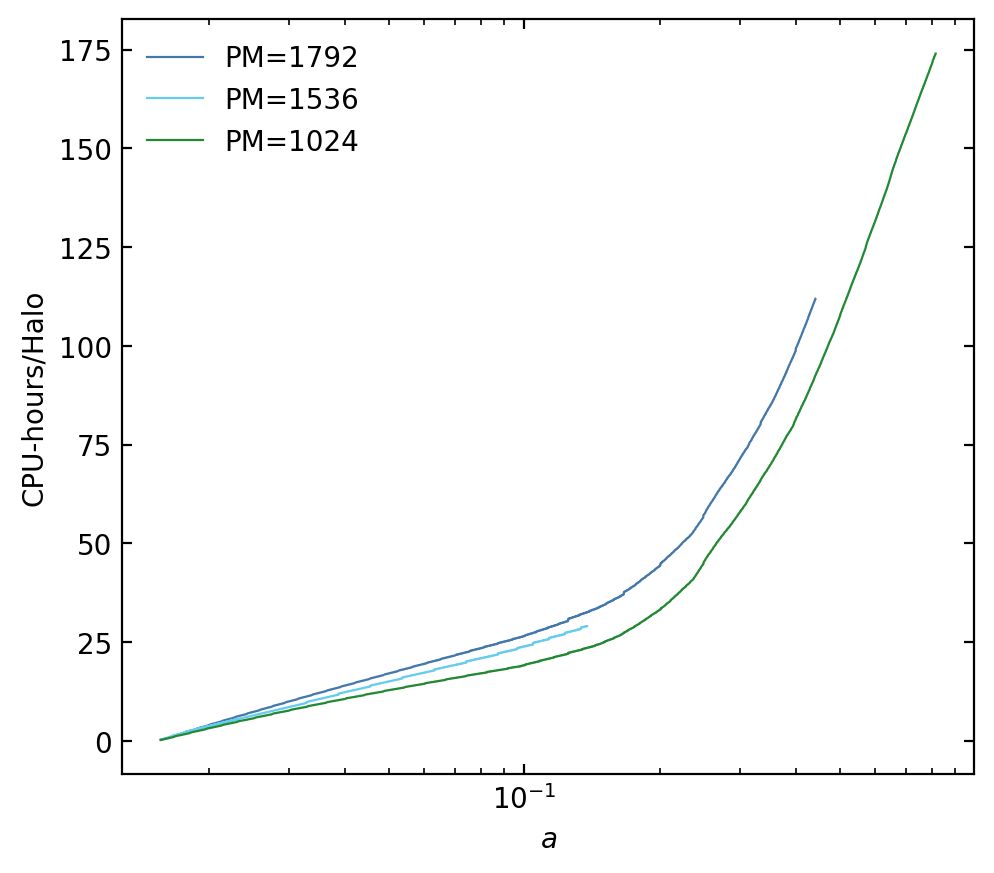

In [82]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')
#ax.set_yscale('log')

ax.plot(data_1792['expfactor'], data_1792['total_cpu'], color=colors[0], label='PM=1792', lw=0.8)
ax.plot(data_1536['expfactor'], data_1536['total_cpu'], color=colors[1], label='PM=1536', lw=0.8)
ax.plot(data_1024['expfactor'], data_1024['total_cpu'], color=colors[2], label='PM=1024', lw=0.8)

#ax.set_ylim(0,50)

ax.legend(loc='upper left')

ax.set_xlabel('$a$')
ax.set_ylabel('CPU-hours/Halo')

### Now let's compare the scaling of different number of halos

In [105]:
base = "/cosmos_storage/data_sharing/MN5_resims/PM_1536/halos_100/"
data_100_1536 = load_scaling(base, 560, 100)

base = "/cosmos_storage/data_sharing/MN5_resims/PM_1536/halos_1000/"
data_1000_1536 = load_scaling(base, 560, 1000)

Get total mass of each selection

In [94]:
sel_10 = np.loadtxt('/cosmos_storage/data_sharing/MN5_resims/PM_1536/halos_10/vmax_custom_sel_10.txt', int)
sel_100 = np.loadtxt('/cosmos_storage/data_sharing/MN5_resims/PM_1536/halos_100/vmax_custom_sel_100.txt', int)
sel_1000 = np.loadtxt('/cosmos_storage/data_sharing/MN5_resims/PM_1536/halos_1000/vmax_custom_sel_1000.txt', int)

In [95]:
basedir = "/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/"

resolution_level = 1

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME
numpart = int(1080**3*2**(3-3*resolution_level))

mtng_dm = bacco.Simulation(basedir=basedir, halo_file="groups_264/fof_subhalo_tab_264", sim_format='TNG500', fixedPk=True, sigma8=sigma8,\
    tau=tau, ns=ns, numpart=numpart, use_orphans=False)

2024-07-15 14:29:27,091 bacco.sims : Initialising simulation Default
2024-07-15 14:29:27,093 bacco.sims : try /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/groups_264/fof_subhalo_tab_264
2024-07-15 14:29:27,096 bacco.sims : Loading /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/groups_264/fof_subhalo_tab_264
2024-07-15 14:29:27,109 bacco.sims : ...done in 0.0122 s


In [98]:
m_10 = np.sum(mtng_dm.fof['halo_m200b'][sel_10])
m_100 = np.sum(mtng_dm.fof['halo_m200b'][sel_100])
m_1000 = np.sum(mtng_dm.fof['halo_m200b'][sel_1000])

Text(0, 0.5, 'CPU-hours$/M_{\\odot}$')

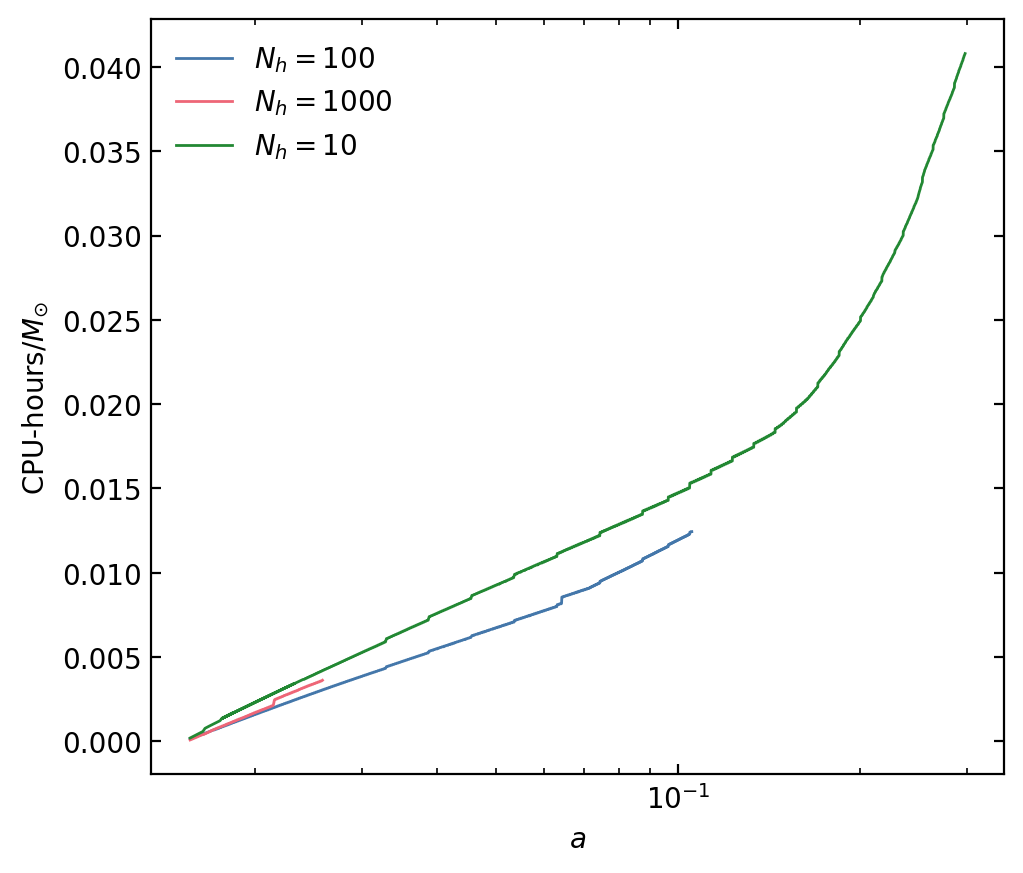

In [109]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')
#ax.set_yscale('log')

ax.plot(data_100_1536['expfactor'], data_100_1536['total_cpu'] * 100 / m_100, color=colors[0], label='$N_h=100$', lw=1)
ax.plot(data_1000_1536['expfactor'], data_1000_1536['total_cpu'] * 1000 / m_1000, color=colors[4], label='$N_h=1000$', lw=1)
ax.plot(data_1536['expfactor'], data_1536['total_cpu'] * 10 / m_10, color=colors[2], label='$N_h=10$', lw=1)

#ax.set_ylim(0,50)

ax.legend(loc='upper left')

ax.set_xlabel('$a$')
ax.set_ylabel('CPU-hours$/M_{\odot}$')